# Model Comparison: Baseline + New Experiments

Synthesises forecasts from:
- `baseline/dam_summary_pred.csv` (DAM, 2024)
- `baseline/imb_pred.df.csv` (IMB, 2023)
- `scripts/raw_forecast/dam/` (new DAM temporal experiments)
- `scripts/raw_forecast/imb/` (new IMB temporal experiments)

**Sections:**
1. MAE / RMSE of DAM forecasts (2024)
2. Per-QH MAE / RMSE of IMB forecasts (2023)
3. SFM Forecasts vs Actual Prices (scatter)
4. Accuracy across price deciles (DAM & IMB)

## 0. Imports & helpers

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression

sys.path.append('..')
from scripts.utils import mean_absolute_error, root_mean_squared_error, load_dataset

RAW_DAM = '../scripts/raw_forecast/dam'
RAW_IMB = '../scripts/raw_forecast/imb'
TEMPLATE = 'seaborn'

## 1. DAM — MAE and RMSE (2024)

### 1a. Load baseline DAM forecasts

In [2]:
dam_df = pd.read_csv('dam_summary_point.csv')
print('Baseline DAM shape:', dam_df.shape)
print('Columns:', dam_df.columns.tolist())

Baseline DAM shape: (8784, 18)
Columns: ['Date', 'timesfm25_1024_AR_neg', 'chronos2_8192_ARX_temporal', 'chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'chronos2_1024_ARX_temporal', 'timesfm25_2048_AR_neg', 'price', 'price_decile', 'chronosbolt_AR', 'timesfm25_1024_AR_neg.1', 'LEAR', 'DNN', 'ens_ml', 'persistent', 'chronos2_1024_AR', 'chronos2_2048_AR', 'chronos2_8192_AR']


### 1b. generate ensemble by averaging

In [9]:
dam_df['ens_chronos_ml'] = dam_df[['ens_ml','chronos2_8192_ARX_temporal']].mean(axis=1)

### 1c. Compute MAE & RMSE for all DAM models

In [12]:
skip_cols = {'price', 'price_decile','Date'}
dam_metrics = []
for col in dam_df.columns:
    print(col)
    if col in skip_cols:
        continue
    mae = mean_absolute_error(dam_df['price'].values, dam_df[col].values)
    rmse = root_mean_squared_error(dam_df['price'].values, dam_df[col].values)
    dam_metrics.append({'Model': col, 'MAE': mae, 'RMSE': rmse})

dam_metrics_df = pd.DataFrame(dam_metrics).sort_values('MAE').reset_index(drop=True)
dam_metrics_df[['MAE','RMSE']] = dam_metrics_df[['MAE','RMSE']].round(3)
dam_metrics_df

Date
timesfm25_1024_AR_neg
chronos2_8192_ARX_temporal
chronos2_2048_ARX_temporal
timesfm25_8192_AR_neg
chronos2_1024_ARX_temporal
timesfm25_2048_AR_neg
price
price_decile
chronosbolt_AR
timesfm25_1024_AR_neg.1
LEAR
DNN
ens_ml
persistent
chronos2_1024_AR
chronos2_2048_AR
chronos2_8192_AR
ens_chronos_ml


,Model,MAE,RMSE
0,ens_chronos_ml,12.303,18.912
1,chronos2_8192_ARX_temporal,12.434,19.363
2,chronos2_2048_ARX_temporal,12.580,19.510
3,chronos2_1024_ARX_temporal,12.774,19.801
4,ens_ml,13.222,19.719
5,LEAR,13.738,20.385
6,DNN,14.386,20.983
7,chronos2_8192_AR,15.607,23.278
8,chronos2_2048_AR,15.666,23.386
9,chronos2_1024_AR,15.809,23.549


In [13]:
print(dam_metrics_df.to_latex(index=False, float_format='{:.3f}'.format))

\begin{tabular}{lrr}
\toprule
Model & MAE & RMSE \\
\midrule
ens_chronos_ml & 12.303 & 18.912 \\
chronos2_8192_ARX_temporal & 12.434 & 19.363 \\
chronos2_2048_ARX_temporal & 12.580 & 19.510 \\
chronos2_1024_ARX_temporal & 12.774 & 19.801 \\
ens_ml & 13.222 & 19.719 \\
LEAR & 13.738 & 20.385 \\
DNN & 14.386 & 20.983 \\
chronos2_8192_AR & 15.607 & 23.278 \\
chronos2_2048_AR & 15.666 & 23.386 \\
chronos2_1024_AR & 15.809 & 23.549 \\
chronosbolt_AR & 16.033 & 24.006 \\
timesfm25_8192_AR_neg & 16.279 & 24.131 \\
timesfm25_2048_AR_neg & 16.823 & 24.715 \\
timesfm25_1024_AR_neg.1 & 16.952 & 25.073 \\
timesfm25_1024_AR_neg & 16.952 & 25.073 \\
persistent & 28.221 & 40.991 \\
\bottomrule
\end{tabular}



### 1d. DM test - TODO

## 2. IMB — Per-QH MAE and RMSE (2023)

### 2a. Load baseline IMB forecasts & calculate ensemble

In [21]:
imb_df = pd.read_csv('imb_summary_point.csv').drop(columns='QH.1')

print('Baseline IMB shape:', imb_df.shape)
print('Columns:', imb_df.columns.tolist())

Baseline IMB shape: (280256, 23)
Columns: ['timestamp', 'price', 'QH', 'chronosbolt_AR', 'chronos2_AR', 'timesfm25_1024_AR_neg', 'DNN_2023_large', 'XGB_2023_medium', 'DNN_2023_small', 'LEAR_2023_medium', 'DNN_2023_medium', 'LEAR_2023_large', 'LEAR_2023_small', 'XGB_2023_large', 'XGB_2023_small', 'ens_ml', 'chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'chronos2_1024_AR', 'chronos2_1024_ARX_temporal', 'timesfm25_2048_AR_neg', 'chronos2_512_ARX_temporal', 'chronos2_2048_AR']


In [24]:
imb_df['ens_chronos_ml'] = imb_df[['ens_ml','chronos2_2048_ARX_temporal']].mean(axis=1)

### 2b. Per-QH MAE and RMSE for all IMB models

In [26]:
# ---- baseline models ----
skip_imb = {'QH', 'price','timestamp'}
mae_all = pd.DataFrame()
rmse_all = pd.DataFrame()

errors_base = imb_df.copy()
se_base = imb_df.copy()

for col in imb_df.columns:
    # print(col)
    if col in skip_imb:
        continue
    errors_base[col] = (imb_df[col] - imb_df['price']).abs()
    se_base[col] = (imb_df[col] - imb_df['price']) ** 2

for col in imb_df.columns:
    # print(col)
    if col in skip_imb:
        continue
    mae_all[col] = errors_base.groupby('QH')[col].mean()
    rmse_all[col] = np.sqrt(se_base.groupby('QH')[col].mean())

print('MAE per QH:')
mae_all.round(2)

MAE per QH:


,chronosbolt_AR,chronos2_AR,timesfm25_1024_AR_neg,DNN_2023_large,XGB_2023_medium,DNN_2023_small,LEAR_2023_medium,DNN_2023_medium,LEAR_2023_large,LEAR_2023_small,...,XGB_2023_small,ens_ml,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_AR,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,chronos2_512_ARX_temporal,chronos2_2048_AR,ens_chronos_ml
QH,,,,,,,,,,,,,,,,,,,,,
1,75.42,72.91,74.39,70.44,70.05,68.69,69.79,73.54,70.11,68.74,...,69.41,67.19,70.09,70.09,73.82,70.87,70.87,72.54,72.91,67.09
2,86.27,83.82,85.75,80.96,81.93,80.48,81.89,84.00,81.59,80.75,...,81.51,79.57,80.72,80.72,85.00,81.79,81.79,83.41,83.82,78.94
3,90.30,88.02,89.93,86.47,87.02,86.95,86.89,89.61,86.95,85.95,...,86.66,85.36,85.33,85.33,89.07,86.36,86.36,87.87,88.02,84.31
4,92.44,90.29,92.15,88.27,88.90,87.87,89.03,90.67,89.65,88.01,...,88.73,87.30,87.73,87.73,91.11,88.73,88.73,90.36,90.29,86.45
5,95.70,93.35,95.52,91.80,93.05,92.22,92.42,94.68,93.81,91.58,...,92.46,91.06,90.69,90.69,94.47,91.88,91.88,93.74,93.35,89.87
6,97.10,94.86,96.96,93.96,94.88,93.78,94.26,96.76,95.94,93.32,...,94.13,92.58,92.29,92.29,96.10,93.54,93.54,95.55,94.86,91.45
7,97.60,95.21,97.59,95.34,95.82,94.53,95.05,98.11,96.95,94.17,...,94.97,93.51,93.09,93.09,96.43,94.39,94.39,96.45,95.21,92.32
8,97.80,95.43,97.78,95.67,95.94,95.13,95.66,97.55,97.59,94.71,...,95.31,93.96,93.71,93.71,96.65,95.05,95.05,97.19,95.43,92.83


In [28]:
print('RMSE per QH:')
rmse_all.round(2)

RMSE per QH:


,chronosbolt_AR,chronos2_AR,timesfm25_1024_AR_neg,DNN_2023_large,XGB_2023_medium,DNN_2023_small,LEAR_2023_medium,DNN_2023_medium,LEAR_2023_large,LEAR_2023_small,...,XGB_2023_small,ens_ml,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_AR,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,chronos2_512_ARX_temporal,chronos2_2048_AR,ens_chronos_ml
QH,,,,,,,,,,,,,,,,,,,,,
1,114.21,115.08,113.86,107.35,103.37,108.32,103.23,111.24,103.88,105.58,...,104.63,104.15,108.14,108.14,117.64,110.77,110.77,112.14,115.08,104.29
2,125.75,125.56,126.44,119.87,117.33,120.02,116.65,124.11,116.68,118.19,...,117.90,117.21,120.52,120.52,128.43,123.03,123.03,124.84,125.56,117.25
3,130.20,129.88,131.13,126.63,123.79,127.53,122.68,130.28,123.29,123.86,...,123.94,123.57,125.73,125.73,131.97,127.65,127.65,129.73,129.88,123.31
4,132.48,132.30,133.55,128.80,125.97,128.87,125.42,131.97,126.31,126.26,...,126.60,126.19,128.56,128.56,133.85,130.35,130.35,132.59,132.30,126.05
5,135.98,135.48,137.27,132.95,130.31,133.20,129.12,136.66,130.95,129.80,...,130.89,130.13,131.90,131.90,137.20,133.63,133.63,136.35,135.48,129.65
6,137.39,136.85,138.82,135.46,132.32,134.58,131.15,138.81,133.34,131.60,...,132.43,131.61,133.55,133.55,138.67,135.13,135.13,138.35,136.85,131.24
7,138.05,137.31,139.41,137.19,133.48,135.54,132.21,140.31,134.60,132.60,...,133.44,132.71,134.33,134.33,139.08,135.87,135.87,139.42,137.31,132.20
8,138.27,137.52,139.67,137.74,133.69,136.61,133.09,139.95,135.52,133.36,...,133.98,133.52,135.13,135.13,139.26,136.60,136.60,140.31,137.52,132.98


In [29]:
# LaTeX: MAE at QH 1, 4, 8
print('MAE at QH 1, 4, 8:')
print(mae_all.T[[1, 4, 8]].round(2).to_latex(float_format='{:.2f}'.format))

MAE at QH 1, 4, 8:
\begin{tabular}{lrrr}
\toprule
QH & 1 & 4 & 8 \\
\midrule
chronosbolt_AR & 75.42 & 92.44 & 97.80 \\
chronos2_AR & 72.91 & 90.29 & 95.43 \\
timesfm25_1024_AR_neg & 74.39 & 92.15 & 97.78 \\
DNN_2023_large & 70.44 & 88.27 & 95.67 \\
XGB_2023_medium & 70.05 & 88.90 & 95.94 \\
DNN_2023_small & 68.69 & 87.87 & 95.13 \\
LEAR_2023_medium & 69.79 & 89.03 & 95.66 \\
DNN_2023_medium & 73.54 & 90.67 & 97.55 \\
LEAR_2023_large & 70.11 & 89.65 & 97.59 \\
LEAR_2023_small & 68.74 & 88.01 & 94.71 \\
XGB_2023_large & 69.75 & 88.52 & 96.70 \\
XGB_2023_small & 69.41 & 88.73 & 95.31 \\
ens_ml & 67.19 & 87.30 & 93.96 \\
chronos2_2048_ARX_temporal & 70.09 & 87.73 & 93.71 \\
timesfm25_8192_AR_neg & 70.09 & 87.73 & 93.71 \\
chronos2_1024_AR & 73.82 & 91.11 & 96.65 \\
chronos2_1024_ARX_temporal & 70.87 & 88.73 & 95.05 \\
timesfm25_2048_AR_neg & 70.87 & 88.73 & 95.05 \\
chronos2_512_ARX_temporal & 72.54 & 90.36 & 97.19 \\
chronos2_2048_AR & 72.91 & 90.29 & 95.43 \\
ens_chronos_ml & 67.09 & 86.

In [30]:
print('RMSE at QH 1, 4, 8:')
print(rmse_all.T[[1, 4, 8]].round(2).to_latex(float_format='{:.2f}'.format))

RMSE at QH 1, 4, 8:
\begin{tabular}{lrrr}
\toprule
QH & 1 & 4 & 8 \\
\midrule
chronosbolt_AR & 114.21 & 132.48 & 138.27 \\
chronos2_AR & 115.08 & 132.30 & 137.52 \\
timesfm25_1024_AR_neg & 113.86 & 133.55 & 139.67 \\
DNN_2023_large & 107.35 & 128.80 & 137.74 \\
XGB_2023_medium & 103.37 & 125.97 & 133.69 \\
DNN_2023_small & 108.32 & 128.87 & 136.61 \\
LEAR_2023_medium & 103.23 & 125.42 & 133.09 \\
DNN_2023_medium & 111.24 & 131.97 & 139.95 \\
LEAR_2023_large & 103.88 & 126.31 & 135.52 \\
LEAR_2023_small & 105.58 & 126.26 & 133.36 \\
XGB_2023_large & 102.99 & 125.78 & 135.05 \\
XGB_2023_small & 104.63 & 126.60 & 133.98 \\
ens_ml & 104.15 & 126.19 & 133.52 \\
chronos2_2048_ARX_temporal & 108.14 & 128.56 & 135.13 \\
timesfm25_8192_AR_neg & 108.14 & 128.56 & 135.13 \\
chronos2_1024_AR & 117.64 & 133.85 & 139.26 \\
chronos2_1024_ARX_temporal & 110.77 & 130.35 & 136.60 \\
timesfm25_2048_AR_neg & 110.77 & 130.35 & 136.60 \\
chronos2_512_ARX_temporal & 112.14 & 132.59 & 140.31 \\
chronos2_2048_

### 2c. DM test per QH - TODO

### 2d. Plot: per-QH MAE (selected models)

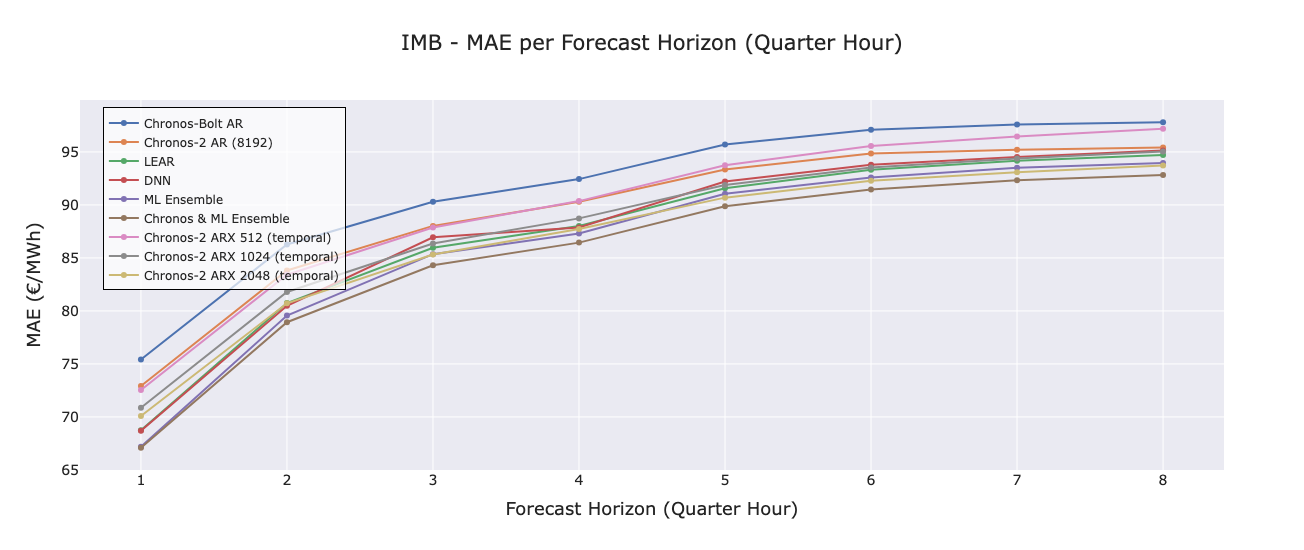

In [32]:
# Select which columns to plot — edit this list as needed

plot_col_imb = [c for c in plot_col_imb if c in mae_all.columns]

col_map_imb = {
    'chronosbolt_AR': 'Chronos-Bolt AR',
    'chronos2_AR': 'Chronos-2 AR (8192)',
    'chronos2_ARX': 'Chronos-2 ARX (8192)',
    'TimesFM_AR': 'TimesFM AR',
    'LEAR_2023_small': 'LEAR',
    'DNN_2023_small': 'DNN',
    'ens_tsfm': 'TSFM Ensemble',
    'ens_ml': 'ML Ensemble',
    'ens_chronos_ml': 'Chronos & ML Ensemble',
    'chronos2_512_ARX_temporal': 'Chronos-2 ARX 512 (temporal)',
    'chronos2_1024_ARX_temporal': 'Chronos-2 ARX 1024 (temporal)',
    'chronos2_2048_ARX_temporal': 'Chronos-2 ARX 2048 (temporal)',
}

fig = go.Figure()
for col in plot_col_imb:
    fig.add_trace(go.Scatter(
        x=mae_all.index,
        y=mae_all[col],
        name=col_map_imb.get(col, col),
        mode='lines+markers'
    ))

fig.update_layout(
    width=900, height=550, template=TEMPLATE,
    font=dict(size=15),
    title='IMB - MAE per Forecast Horizon (Quarter Hour)',
    yaxis=dict(title='MAE (€/MWh)', title_font=dict(size=18), tickfont=dict(size=14)),
    xaxis=dict(title='Forecast Horizon (Quarter Hour)', title_font=dict(size=18), tickfont=dict(size=14)),
    legend=dict(x=0.02, y=0.98, xanchor='left', yanchor='top', font=dict(size=12),
                bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig.update_xaxes(tickmode='array', tickvals=list(range(1, 9)), ticktext=[str(i) for i in range(1, 9)])
fig.show()

## 3. SFM Forecasts vs Actual Prices

### 3a. DAM: SFM scatter plots (predictions vs actual)

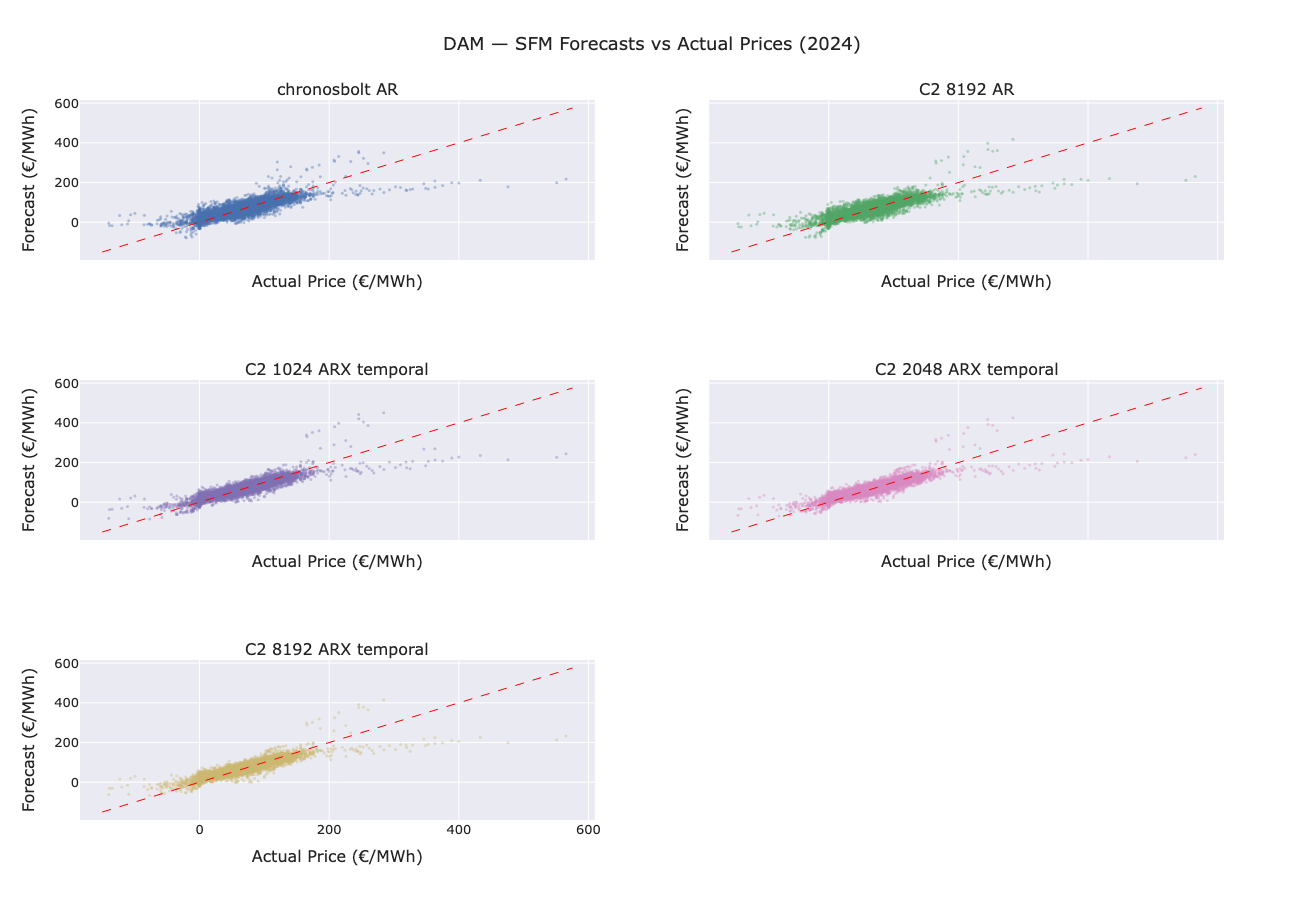

In [33]:
# Core SFM models available in the DAM baseline
dam_sfm_models = [
    'chronos2_8192_ARX_basic', 'chronosbolt_AR', 'chronos2_8192_AR', 'TimesFM_AR',
    'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal', 'chronos2_8192_ARX_temporal',
]
dam_sfm_models = [m for m in dam_sfm_models if m in dam_df.columns]

cols = 2
rows = int(np.ceil(len(dam_sfm_models) / cols))
fig = make_subplots(rows=rows, cols=cols,
                    subplot_titles=[m.replace('chronos2', 'C2').replace('_', ' ') for m in dam_sfm_models],
                    shared_xaxes=True, shared_yaxes=True)

actual = dam_df['price'].values
price_range = [actual.min() - 10, actual.max() + 10]

for i, model in enumerate(dam_sfm_models):
    r, c = divmod(i, cols)
    pred = dam_df[model].values
    fig.add_trace(go.Scatter(
        x=actual, y=pred, mode='markers',
        marker=dict(size=3, opacity=0.4),
        name=model, showlegend=False
    ), row=r + 1, col=c + 1)
    # diagonal reference line
    fig.add_trace(go.Scatter(
        x=price_range, y=price_range, mode='lines',
        line=dict(color='red', dash='dash', width=1),
        showlegend=False
    ), row=r + 1, col=c + 1)

fig.update_layout(
    width=900, height=300 * rows, template=TEMPLATE,
    title='DAM — SFM Forecasts vs Actual Prices (2024)',
    font=dict(size=13)
)
fig.update_xaxes(title_text='Actual Price (€/MWh)')
fig.update_yaxes(title_text='Forecast (€/MWh)')
fig.show()

### 3b. IMB: SFM scatter plots (predictions vs actual)

In [35]:
# imb_sfm_baseline = ['chronosbolt_AR', 'chronos2_AR', 'chronos2_ARX', 'TimesFM_AR']
# imb_sfm_baseline = [m for m in imb_sfm_baseline if m in imb_df.columns]

# imb_sfm_new_keys = list(new_imb.keys())
all_imb_sfm = mae_all.columns.list()

cols = 2
rows = int(np.ceil(len(all_imb_sfm) / cols))
fig = make_subplots(rows=rows, cols=cols,
                    subplot_titles=[m.replace('chronos2', 'C2').replace('_', ' ') for m in all_imb_sfm],
                    shared_xaxes=True, shared_yaxes=True)

actual_imb = imb_df['price'].values
imb_range = [actual_imb.min() - 20, actual_imb.max() + 20]

for i, model in enumerate(all_imb_sfm):
    r, c = divmod(i, cols)
    if model in imb_df.columns:
        pred = imb_df[model].values
        act = actual_imb
    else:
        d = new_imb[model].dropna()
        pred = d[model].values
        act = d['price'].values
    fig.add_trace(go.Scatter(
        x=act, y=pred, mode='markers',
        marker=dict(size=2, opacity=0.3),
        name=model, showlegend=False
    ), row=r + 1, col=c + 1)
    fig.add_trace(go.Scatter(
        x=imb_range, y=imb_range, mode='lines',
        line=dict(color='red', dash='dash', width=1),
        showlegend=False
    ), row=r + 1, col=c + 1)

fig.update_layout(
    width=900, height=300 * rows, template=TEMPLATE,
    title='IMB — SFM Forecasts vs Actual Prices (2023)',
    font=dict(size=13)
)
fig.update_xaxes(title_text='Actual Price (€/MWh)')
fig.update_yaxes(title_text='Forecast (€/MWh)')
fig.show()

AttributeError: 'Index' object has no attribute 'list'

## 4. Accuracy across Price Deciles

### 4a. DAM — decile MAE and RMSE

In [38]:
dam_df

,Date,timesfm25_1024_AR_neg,chronos2_8192_ARX_temporal,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,price,price_decile,chronosbolt_AR,timesfm25_1024_AR_neg.1,LEAR,DNN,ens_ml,persistent,chronos2_1024_AR,chronos2_2048_AR,chronos2_8192_AR,ens_chronos_ml
0,2024-01-01 00:00:00,-1.732063,-0.993057,0.158455,-1.811249,0.498779,-2.116943,0.10,1,1.285957,-1.732063,-3.704949,-2.598481,-3.151715,-3.91,-0.381310,0.932976,0.342308,-2.072386
1,2024-01-01 01:00:00,-3.823929,-3.589729,-1.903648,-3.909737,-1.571457,-3.696365,0.01,1,0.009575,-3.823929,-11.535979,-6.427956,-8.981967,-8.37,-1.236465,0.244629,-0.666992,-6.285848
2,2024-01-01 02:00:00,-4.881111,-5.421745,-3.554909,-3.852104,-2.527191,-4.213196,0.00,1,-1.298004,-4.881111,-14.719947,-11.462571,-13.091259,-10.00,-1.154526,0.337433,-0.427330,-9.256502
3,2024-01-01 03:00:00,-8.487267,-7.023384,-5.301277,-6.718201,-4.438095,-7.082481,-0.01,1,-2.085915,-8.487259,-18.346627,-12.476321,-15.411474,-11.80,-1.951279,-0.431137,-1.630852,-11.217429
4,2024-01-01 04:00:00,-8.944267,-6.586365,-5.622032,-6.904182,-4.524193,-7.531990,-0.03,1,-2.226128,-8.944252,-16.963710,-11.174688,-14.069199,-11.12,-2.440201,-1.013756,-2.081856,-10.327782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,126.298280,99.956240,99.641620,127.122190,102.174500,125.531110,81.30,7,124.514830,126.298310,97.899953,121.473579,109.686766,105.66,120.695625,124.396400,120.537186,104.821503
8780,2024-12-31 20:00:00,116.506820,87.685930,86.124245,117.867550,89.029140,116.505040,45.60,3,112.713600,116.506850,83.666728,112.203552,97.935140,102.56,108.790215,112.487946,111.896290,92.810535
8781,2024-12-31 21:00:00,105.073105,75.887650,75.064380,106.783646,78.372475,106.104780,17.60,2,104.126230,105.073140,83.242242,107.962624,95.602433,94.63,100.658300,104.407080,103.863815,85.745041
8782,2024-12-31 22:00:00,99.216480,72.960750,72.206000,102.145546,76.467350,101.872830,4.04,1,99.613014,99.216490,83.416296,103.536430,93.476363,99.04,96.782234,100.833540,99.173050,83.218557


In [40]:
# Rebuild price_decile to include any new models
# dam_df['price_decile'] = pd.qcut(dam_df['price'], q=10, labels=False) + 1

dam_model_cols = [c for c in dam_df.columns if c not in {'price', 'price_decile','Date'}]

decile_mae_dam = pd.DataFrame()
decile_rmse_dam = pd.DataFrame()
ae_tmp = dam_df[['price_decile']].copy()
se_tmp = dam_df[['price_decile']].copy()

for col in dam_model_cols:
    ae_tmp[col] = (dam_df[col] - dam_df['price']).abs()
    se_tmp[col] = (dam_df[col] - dam_df['price']) ** 2
    decile_mae_dam[col] = ae_tmp.groupby('price_decile')[col].mean()
    decile_rmse_dam[col] = np.sqrt(se_tmp.groupby('price_decile')[col].mean())

print('DAM decile MAE:')
decile_mae_dam.round(2)

DAM decile MAE:


,timesfm25_1024_AR_neg,chronos2_8192_ARX_temporal,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,chronosbolt_AR,timesfm25_1024_AR_neg.1,LEAR,DNN,ens_ml,persistent,chronos2_1024_AR,chronos2_2048_AR,chronos2_8192_AR,ens_chronos_ml
price_decile,,,,,,,,,,,,,,,,
1,24.27,19.36,18.48,26.21,18.81,24.49,24.16,24.27,19.78,20.01,19.17,38.50,22.49,22.61,23.42,18.84
2,17.96,14.91,14.70,19.00,14.98,18.53,18.55,17.96,14.87,17.25,15.31,32.69,17.95,17.85,18.25,14.67
3,14.42,10.86,11.13,14.10,11.36,14.65,14.61,14.42,11.76,12.78,11.44,24.75,14.57,14.37,14.56,10.61
4,11.94,9.22,9.40,11.27,9.32,12.09,12.12,11.94,10.63,10.57,9.92,20.55,11.53,11.61,11.78,9.07
5,12.96,9.08,9.32,12.07,9.23,12.75,12.34,12.96,10.78,10.87,10.03,21.85,11.82,11.94,12.03,9.15
6,13.94,9.81,10.00,12.65,10.02,13.65,12.34,13.94,11.23,11.69,10.58,25.39,12.68,12.48,12.17,9.65
7,14.27,9.60,9.69,13.00,9.94,13.91,13.00,14.27,11.64,11.59,10.70,27.77,12.98,12.77,12.36,9.61
8,15.17,9.29,9.57,13.14,9.87,14.58,12.80,15.17,11.37,12.24,10.84,25.28,13.04,12.79,12.29,9.45
9,16.36,10.93,11.38,13.87,11.68,15.67,13.91,16.36,13.07,13.71,12.45,26.99,13.87,13.48,13.11,11.12


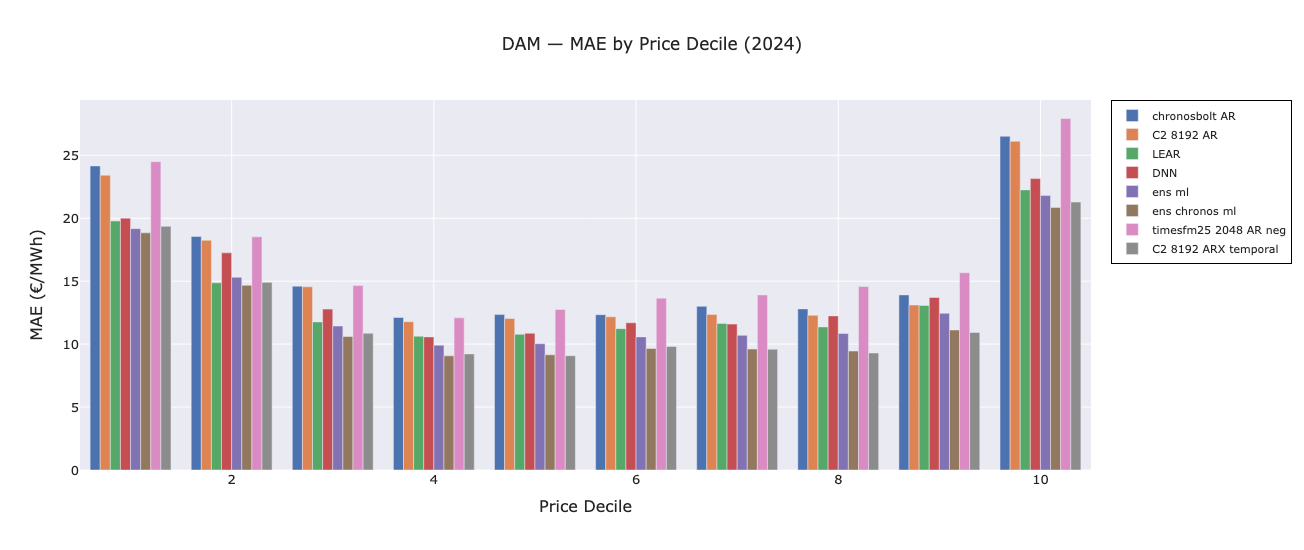

In [43]:
# Select a readable subset for display
dam_display = [
    'chronosbolt_AR', 'chronos2_8192_AR', #'TimesFM_AR',
    'LEAR', 'DNN',  'ens_ml', 'ens_chronos_ml','timesfm25_2048_AR_neg',
     'chronos2_8192_ARX_temporal',# 'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal','ens_tsfm',
]
# dam_display = [c for c in dam_display if c in decile_mae_dam.columns]

fig = go.Figure()
for col in dam_display:
    fig.add_trace(go.Bar(
        x=decile_mae_dam.index,
        y=decile_mae_dam[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='DAM — MAE by Price Decile (2024)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='MAE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig.show()

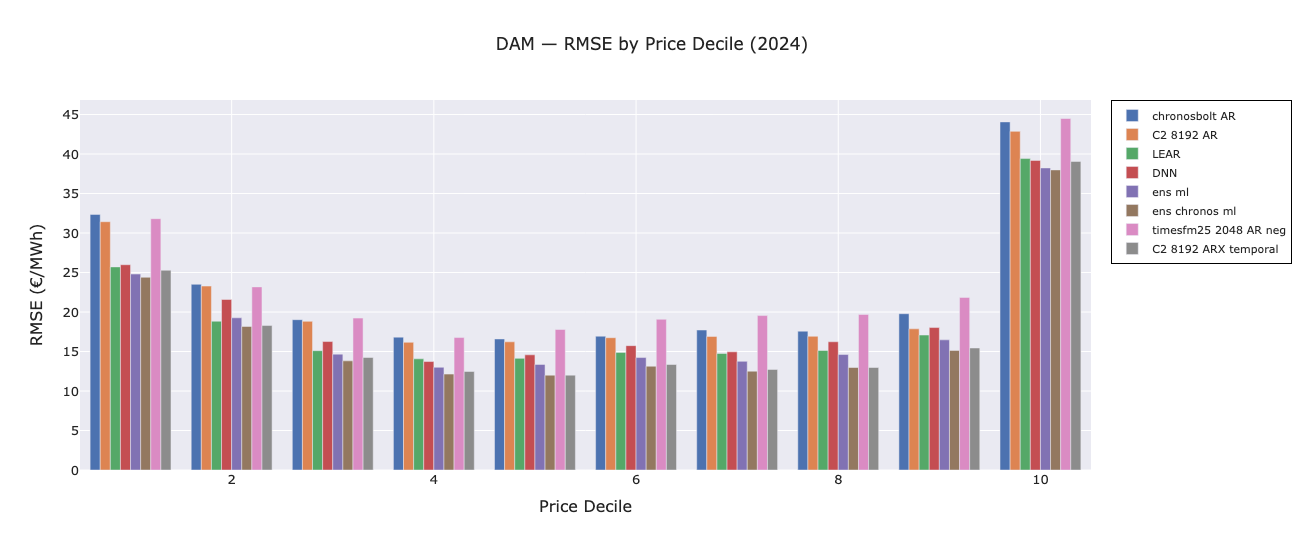

In [44]:
fig2 = go.Figure()
for col in dam_display:
    fig2.add_trace(go.Bar(
        x=decile_rmse_dam.index,
        y=decile_rmse_dam[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig2.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='DAM — RMSE by Price Decile (2024)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='RMSE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig2.show()

In [45]:
# LaTeX: decile MAE at deciles 1, 5, 10
print(decile_mae_dam[dam_display].T[[1, 5, 10]].round(2).to_latex(float_format='{:.2f}'.format))

\begin{tabular}{lrrr}
\toprule
price_decile & 1 & 5 & 10 \\
\midrule
chronosbolt_AR & 24.16 & 12.34 & 26.51 \\
chronos2_8192_AR & 23.42 & 12.03 & 26.11 \\
LEAR & 19.78 & 10.78 & 22.25 \\
DNN & 20.01 & 10.87 & 23.15 \\
ens_ml & 19.17 & 10.03 & 21.80 \\
ens_chronos_ml & 18.84 & 9.15 & 20.86 \\
timesfm25_2048_AR_neg & 24.49 & 12.75 & 27.92 \\
chronos2_8192_ARX_temporal & 19.36 & 9.08 & 21.28 \\
\bottomrule
\end{tabular}



### 4b. IMB — decile MAE and RMSE (using baseline + new models)

In [49]:
imb_df['price_decile'] = pd.qcut(imb_df['price'], q=10, labels=False) + 1

imb_model_cols = [c for c in imb_df.columns if c not in {'QH', 'price', 'price_decile','timestamp'}]

decile_mae_imb = pd.DataFrame()
decile_rmse_imb = pd.DataFrame()
ae_imb = imb_df[['price_decile']].copy()
se_imb = imb_df[['price_decile']].copy()

for col in imb_model_cols:
    ae_imb[col] = (imb_df[col] - imb_df['price']).abs()
    se_imb[col] = (imb_df[col] - imb_df['price']) ** 2
    decile_mae_imb[col] = ae_imb.groupby('price_decile')[col].mean()
    decile_rmse_imb[col] = np.sqrt(se_imb.groupby('price_decile')[col].mean())

# Add new raw IMB models (need to assign deciles using actual price from imb_df price range)
# for model_name, df_new in new_imb.items():
#     df_new = df_new.dropna().copy()
#     df_new['price_decile'] = pd.qcut(df_new['price'], q=10, labels=False) + 1
#     df_new['AE'] = (df_new[model_name] - df_new['price']).abs()
#     df_new['SE'] = (df_new[model_name] - df_new['price']) ** 2
#     decile_mae_imb[model_name] = df_new.groupby('price_decile')['AE'].mean()
#     decile_rmse_imb[model_name] = np.sqrt(df_new.groupby('price_decile')['SE'].mean())

print('IMB decile MAE:')
decile_mae_imb.round(2)

IMB decile MAE:


,chronosbolt_AR,chronos2_AR,timesfm25_1024_AR_neg,DNN_2023_large,XGB_2023_medium,DNN_2023_small,LEAR_2023_medium,DNN_2023_medium,LEAR_2023_large,LEAR_2023_small,...,XGB_2023_small,ens_ml,chronos2_2048_ARX_temporal,timesfm25_8192_AR_neg,chronos2_1024_AR,chronos2_1024_ARX_temporal,timesfm25_2048_AR_neg,chronos2_512_ARX_temporal,chronos2_2048_AR,ens_chronos_ml
price_decile,,,,,,,,,,,,,,,,,,,,,
1,226.56,217.78,226.50,210.89,209.04,212.07,200.17,224.60,206.17,206.37,...,209.87,209.05,211.92,211.92,219.89,214.26,214.26,216.55,217.78,210.01
2,97.28,90.67,93.81,78.22,82.66,81.16,81.11,98.90,84.14,81.60,...,83.60,80.79,82.84,82.84,90.54,85.27,85.27,86.53,90.67,80.64
3,87.49,85.95,86.86,81.31,72.45,81.70,72.24,90.37,76.61,74.33,...,73.82,75.63,79.49,79.49,87.08,81.93,81.93,84.08,85.95,76.58
4,60.17,59.63,58.84,61.66,52.18,62.25,51.75,64.28,57.74,53.32,...,51.78,54.73,56.72,56.72,60.76,58.11,58.11,59.81,59.63,54.66
5,49.92,49.81,49.61,52.45,50.94,54.34,54.72,51.82,57.21,52.73,...,49.72,50.39,49.14,49.14,51.56,50.62,50.62,51.10,49.81,48.50
6,39.68,41.37,41.56,43.49,42.49,39.91,47.30,39.46,45.95,44.03,...,42.26,40.02,38.32,38.32,42.37,39.63,39.63,41.46,41.37,37.72
7,45.31,45.94,45.86,49.61,50.68,46.02,54.31,44.43,52.42,50.98,...,49.22,47.18,44.02,44.02,46.68,44.50,44.50,46.50,45.94,44.08
8,61.96,60.81,62.15,65.68,68.75,62.38,69.95,58.80,66.80,66.10,...,66.44,63.84,60.59,60.59,61.59,60.87,60.87,62.59,60.81,60.99
9,91.19,89.38,91.35,89.02,97.58,88.53,96.81,87.15,93.48,92.82,...,96.42,91.86,91.21,91.21,90.42,90.77,90.77,92.77,89.38,90.61


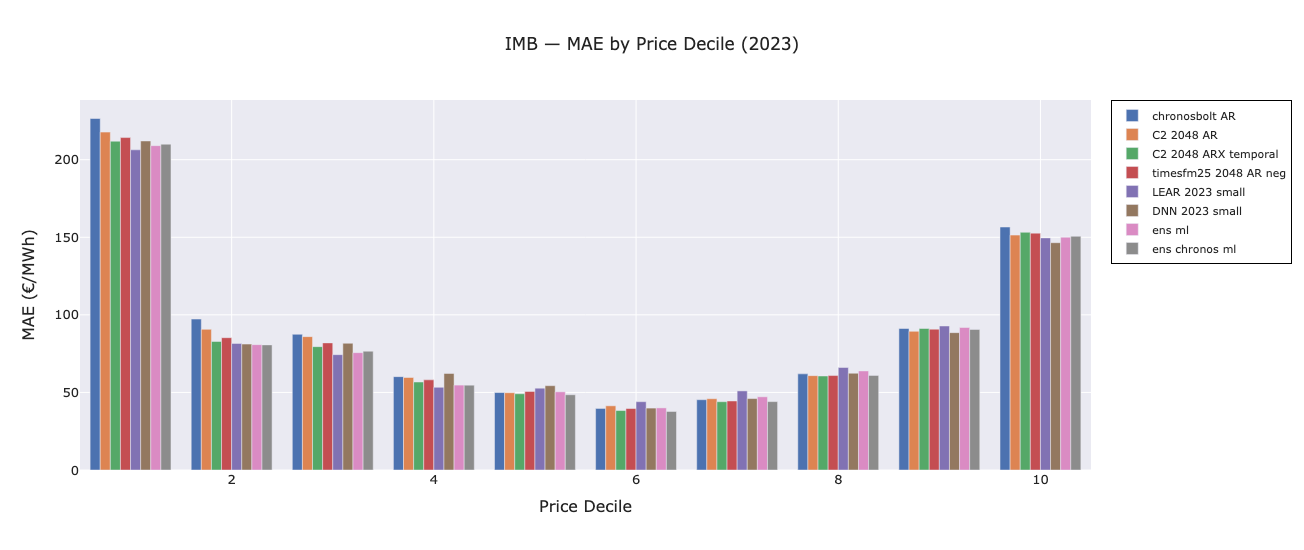

In [50]:
imb_display = [
    'chronosbolt_AR', 'chronos2_2048_AR', 'chronos2_2048_ARX_temporal', 'timesfm25_2048_AR_neg',
    'LEAR_2023_small', 'DNN_2023_small',  'ens_ml', 'ens_chronos_ml',#'ens_tsfm',
    # 'chronos2_512_ARX_temporal', 'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal',
]
imb_display = [c for c in imb_display if c in decile_mae_imb.columns]

fig = go.Figure()
for col in imb_display:
    fig.add_trace(go.Bar(
        x=decile_mae_imb.index,
        y=decile_mae_imb[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='IMB — MAE by Price Decile (2023)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='MAE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig.show()

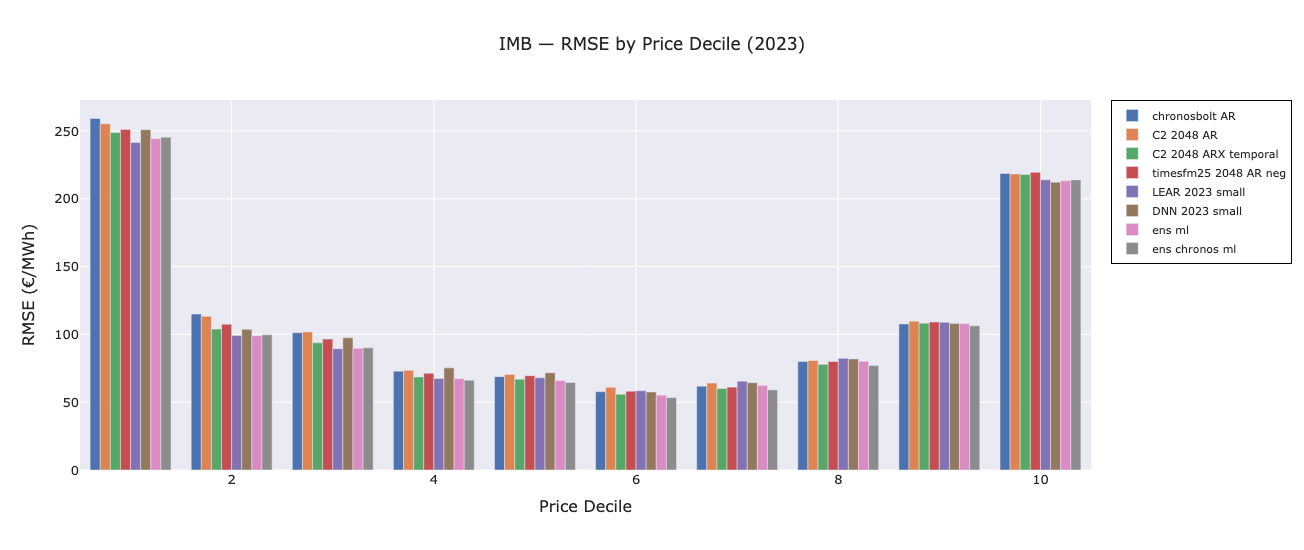

In [51]:
fig2 = go.Figure()
for col in imb_display:
    fig2.add_trace(go.Bar(
        x=decile_rmse_imb.index,
        y=decile_rmse_imb[col],
        name=col.replace('chronos2', 'C2').replace('_', ' '),
    ))

fig2.update_layout(
    barmode='group',
    width=1100, height=550, template=TEMPLATE,
    title='IMB — RMSE by Price Decile (2023)',
    xaxis=dict(title='Price Decile', title_font=dict(size=16), tickfont=dict(size=13)),
    yaxis=dict(title='RMSE (€/MWh)', title_font=dict(size=16), tickfont=dict(size=13)),
    legend=dict(font=dict(size=11), bgcolor='rgba(255,255,255,0.7)', bordercolor='black', borderwidth=1)
)
fig2.show()

In [52]:
# LaTeX: decile MAE at deciles 1, 5, 10
print(decile_mae_imb[imb_display].T[[1, 5, 10]].round(2).to_latex(float_format='{:.2f}'.format))

\begin{tabular}{lrrr}
\toprule
price_decile & 1 & 5 & 10 \\
\midrule
chronosbolt_AR & 226.56 & 49.92 & 156.60 \\
chronos2_2048_AR & 217.78 & 49.81 & 151.39 \\
chronos2_2048_ARX_temporal & 211.92 & 49.14 & 153.20 \\
timesfm25_2048_AR_neg & 214.26 & 50.62 & 152.67 \\
LEAR_2023_small & 206.37 & 52.73 & 149.60 \\
DNN_2023_small & 212.07 & 54.34 & 146.51 \\
ens_ml & 209.05 & 50.39 & 150.03 \\
ens_chronos_ml & 210.01 & 48.50 & 150.66 \\
\bottomrule
\end{tabular}

